# CBA 2026 — Notebook 04: Per-target prediction insights

Per-target story for the CBA 2026 talk. Builds Figs P5–P8:

| Fig | What it shows |
| --- | --- |
| P5 | Top-25 ΔPearson r gainers per family. Bars = ΔPearson r vs RF baseline; ticks = absolute Pearson r at RF baseline (black) and TabPFN+MOSA (focus colour). |
| P6 | y_true vs y_pred deep-dives for MDM2, MDM4 (TP53 biomarkers in the abstract) + the top CRISPR gainer + top three drug gainers. RF baseline overlaid in grey. |
| P7 | Where TabPFN+MOSA helps most: ΔPearson r vs baseline r, vs n_test, MOSA-effect × model-effect quadrant, plus a per-lever bootstrap-mean summary. |
| P8 | Per-target Pearson r across {original, MOSA gaps only, MOSA all} at the *expanded* sample frame; light per-target lines + per-model median trajectory. |

Outputs: `reports/cba2026_claude_union_omicsclin/prediction_analysis/20260511_174623/` (composites) and `…/singles/` (single-panel slide cuts).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

import _prediction_analysis as pred
from IPython.display import Image, display

decomposed = pred.load_decomposed()
summary_long = pred.load_summary_long()
per_target_long = pred.load_per_target_long()

selected = pred.select_deep_dive_targets(decomposed)
print(f"Deep-dive selection: {selected}")

Deep-dive selection: {'crisprcas9': ['MDM2', 'MDM4', 'THOC2'], 'drugresponse': ['KN_93', 'Rosiglitazone_Maleate', 'Daunorubicin_HCl']}


## Figure P5 — top winners per family

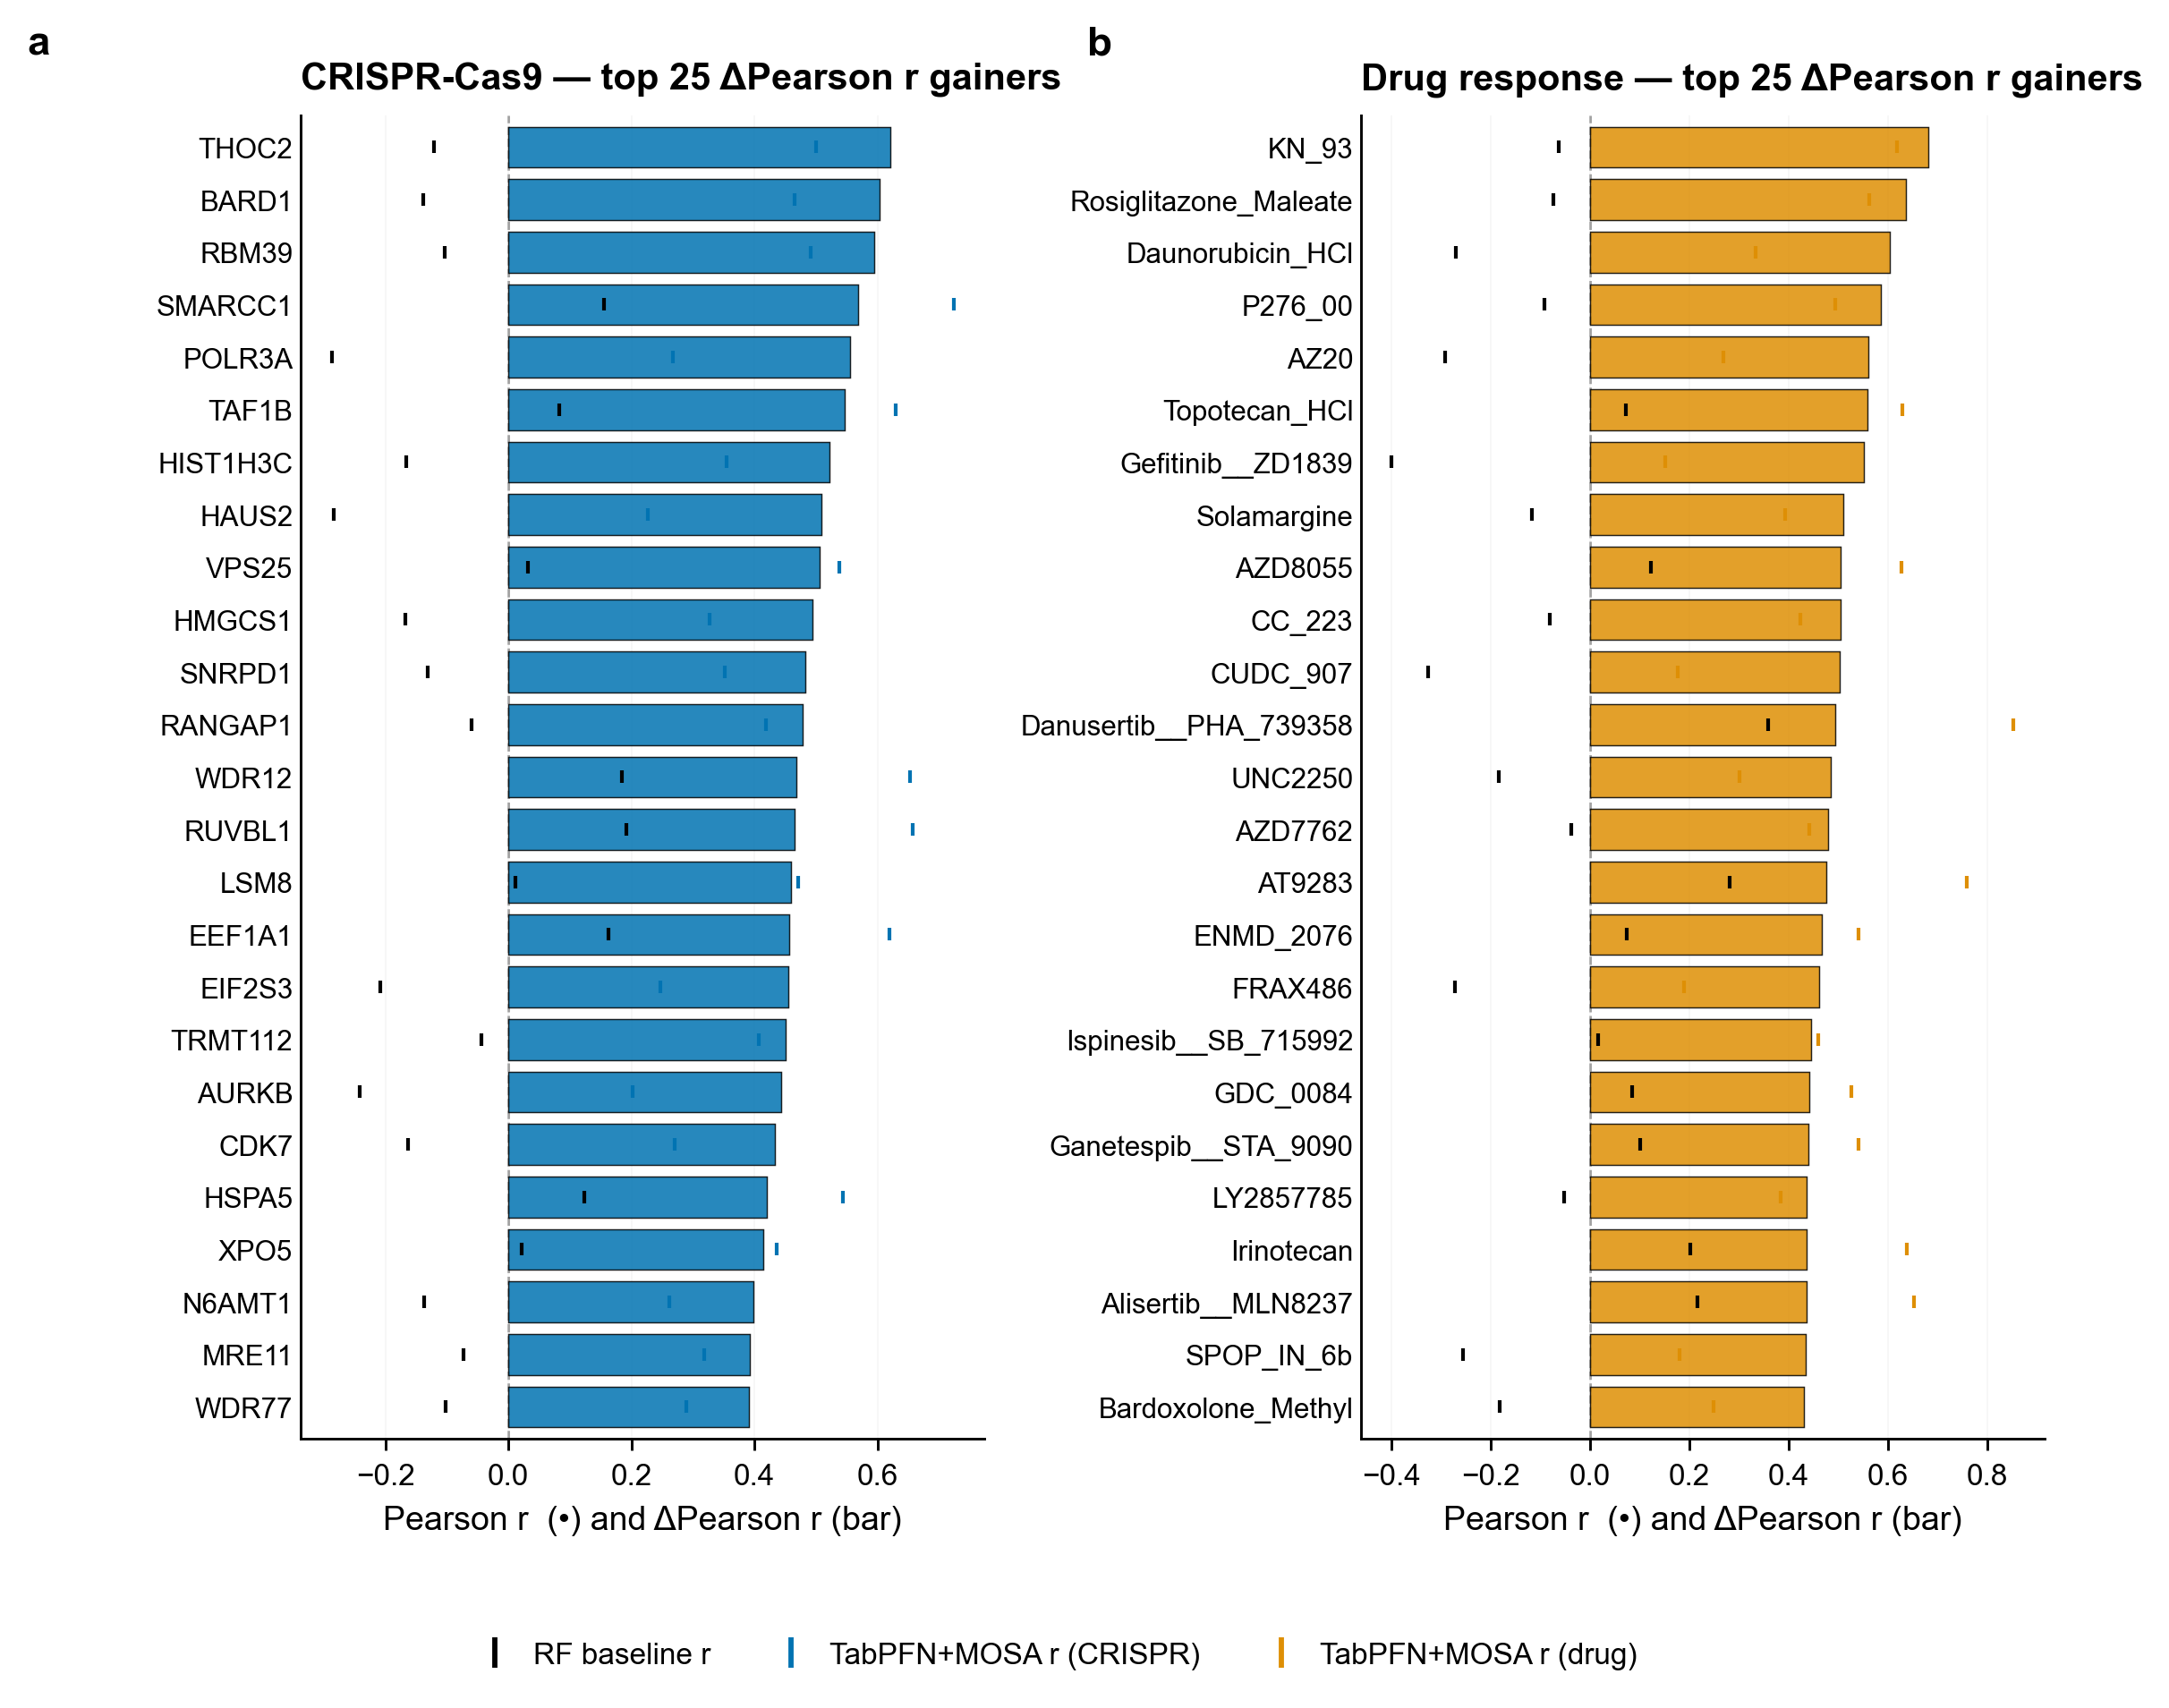

reports/cba2026_claude_union_omicsclin/prediction_analysis/20260511_174623/figP5_top_winners.pdf


In [2]:
p5 = pred.figP5_top_winners(decomposed, top_n=25)
display(Image(filename=str(p5.with_suffix(".png"))))
print(p5.relative_to(pred.ROOT))

## Figure P6 — selected target deep-dives

Six panels (3 CRISPR + 3 drug). Anchors to MDM2 / MDM4 from the abstract; the third CRISPR slot fills with the top CRISPR ΔPearson_r gainer. The drug row is the top three drug gainers.

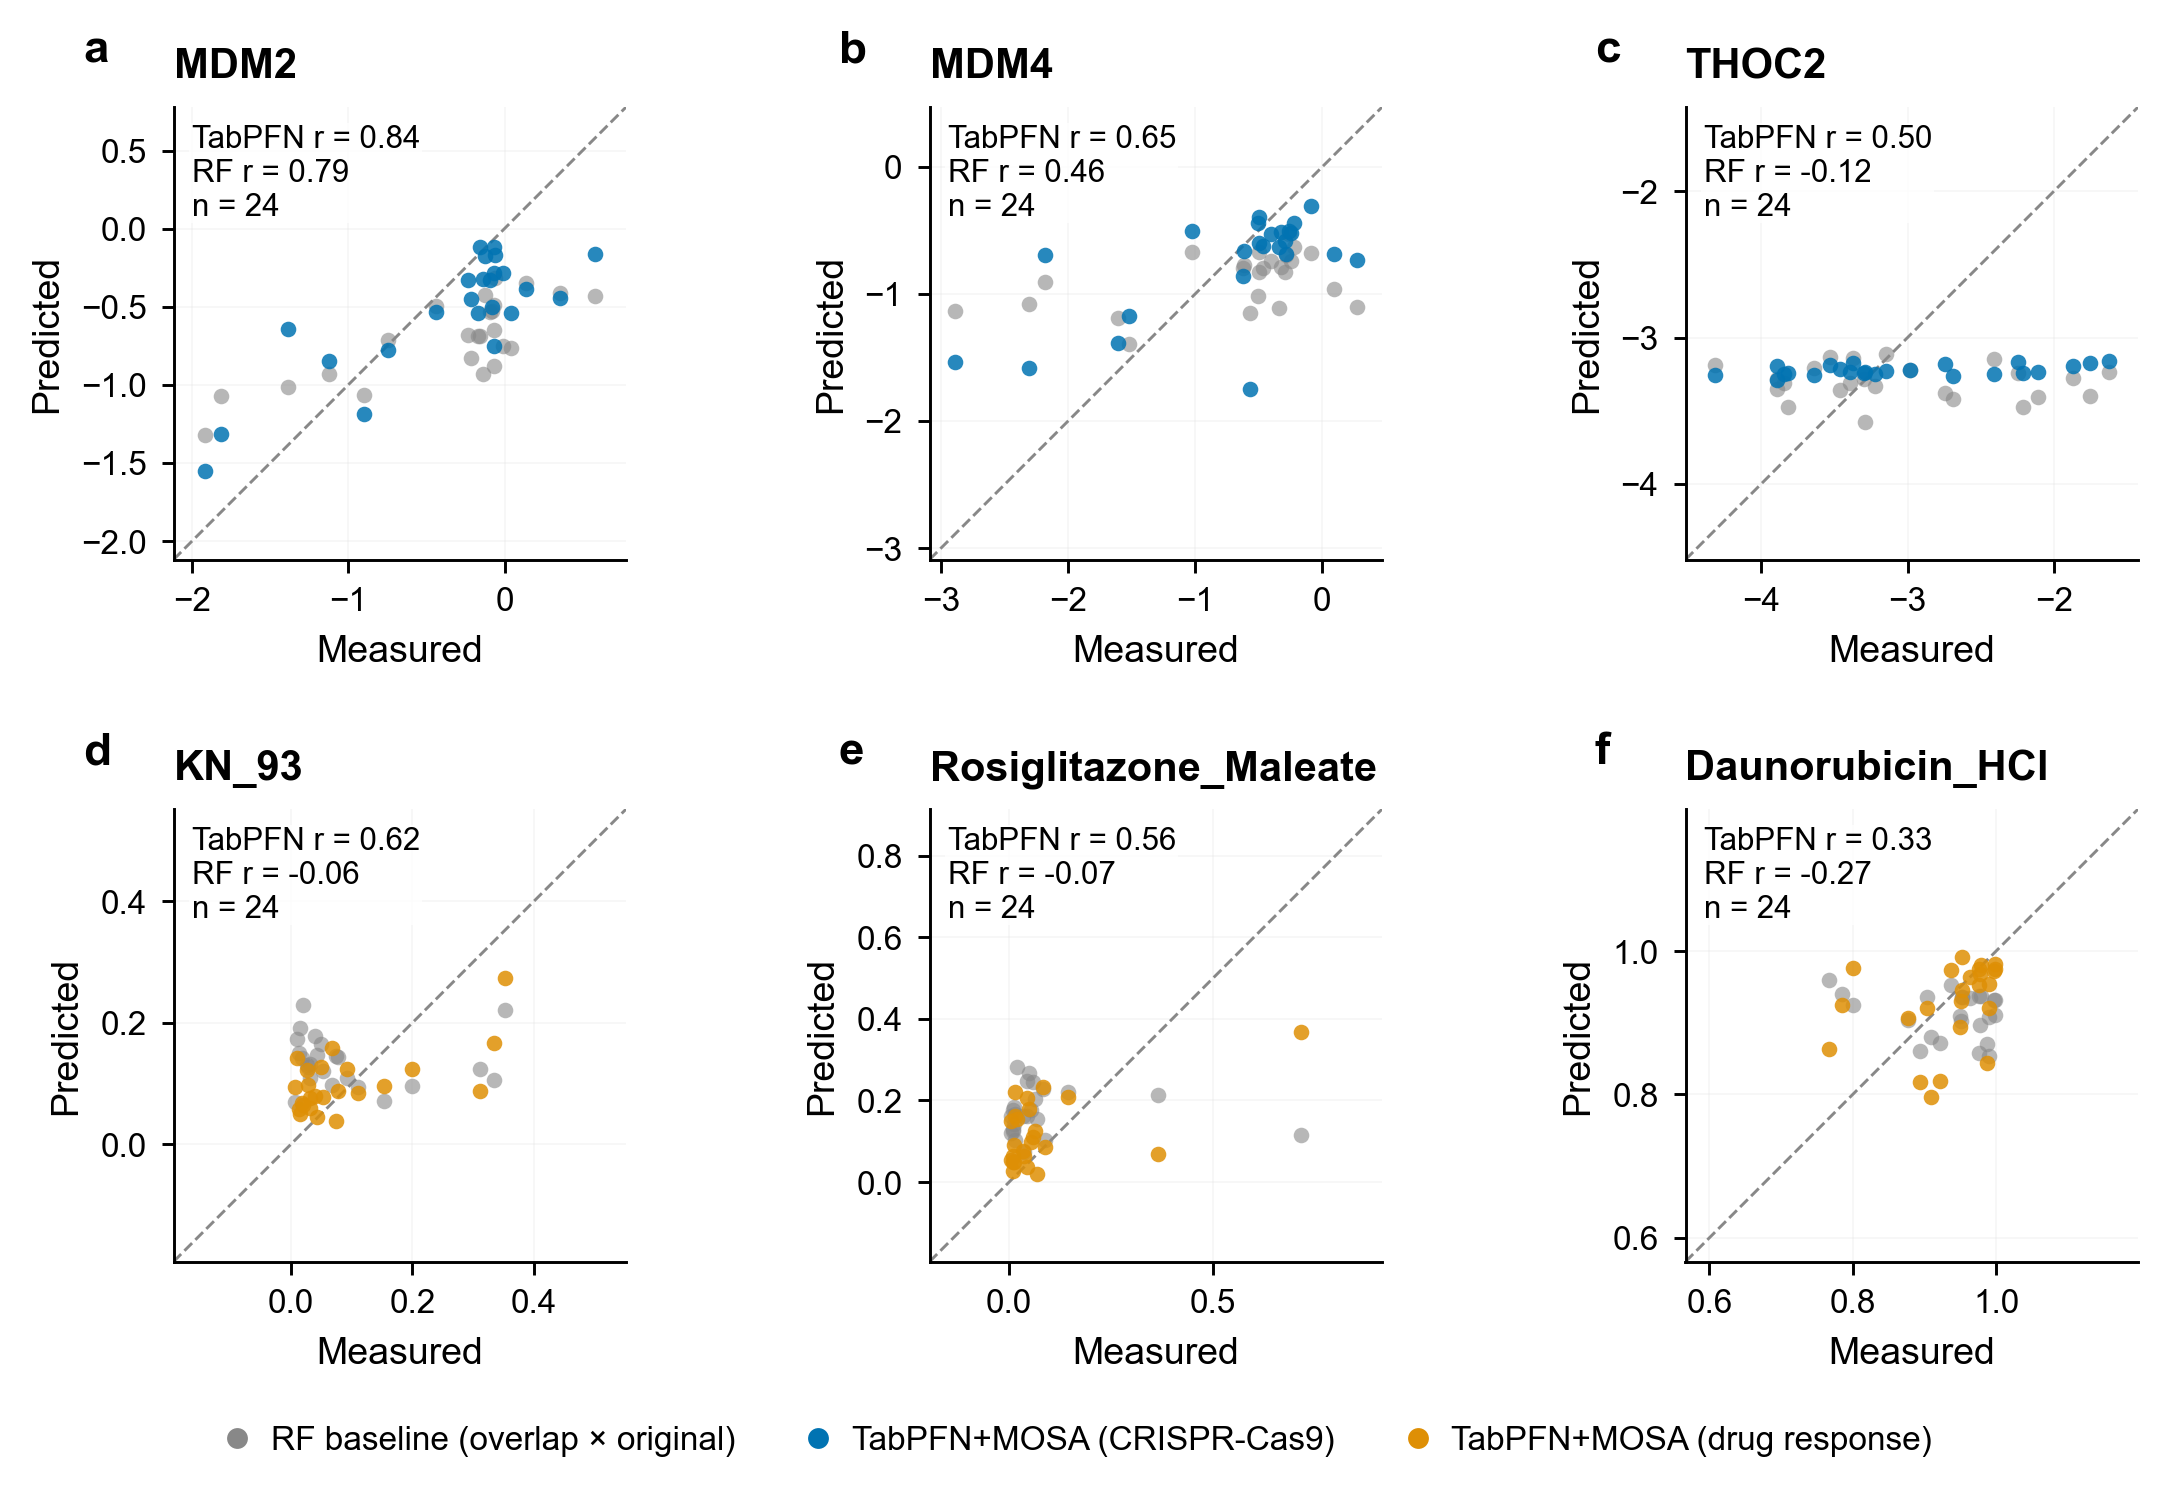

reports/cba2026_claude_union_omicsclin/prediction_analysis/20260511_174623/figP6_target_deepdives.pdf


In [3]:
p6, used_selected = pred.figP6_target_deepdives(decomposed, selected=selected)
display(Image(filename=str(p6.with_suffix(".png"))))
print(p6.relative_to(pred.ROOT))

## Figure P7 — where TabPFN+MOSA helps most

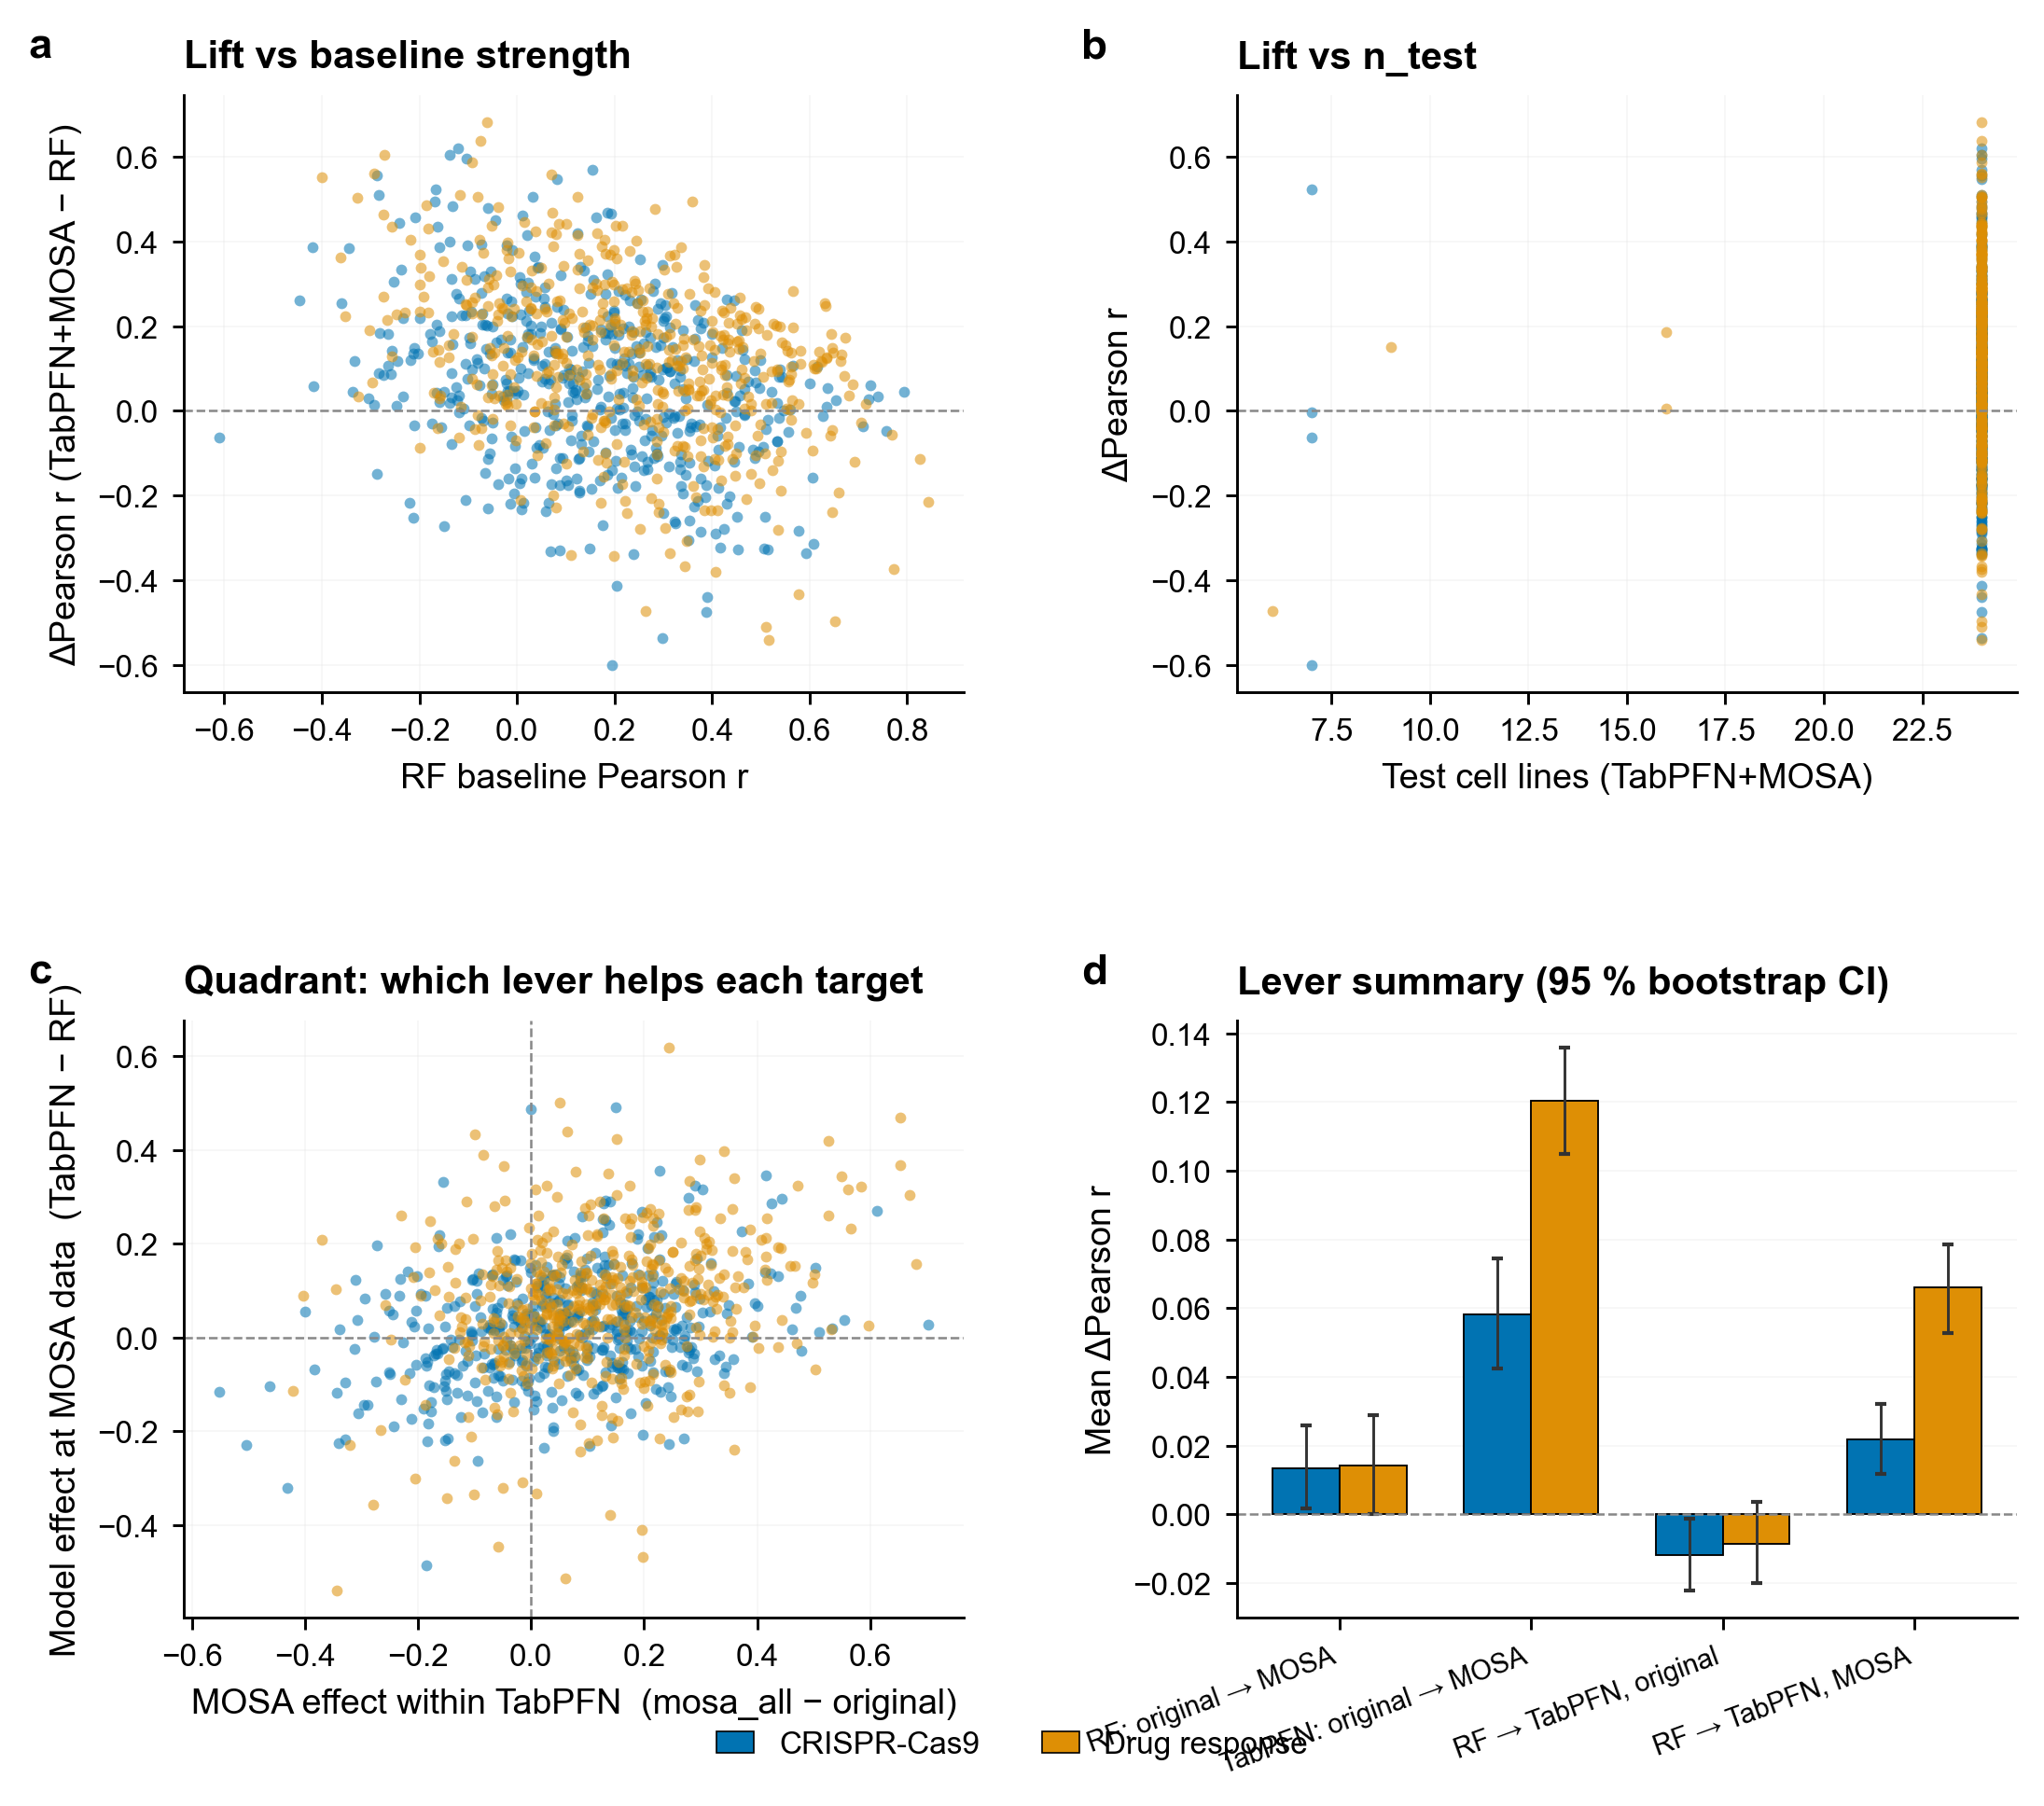

reports/cba2026_claude_union_omicsclin/prediction_analysis/20260511_174623/figP7_helps_most.pdf


In [4]:
p7 = pred.figP7_helps_most(decomposed)
display(Image(filename=str(p7.with_suffix(".png"))))
print(p7.relative_to(pred.ROOT))

## Figure P8 — augmentation strategy at the target level

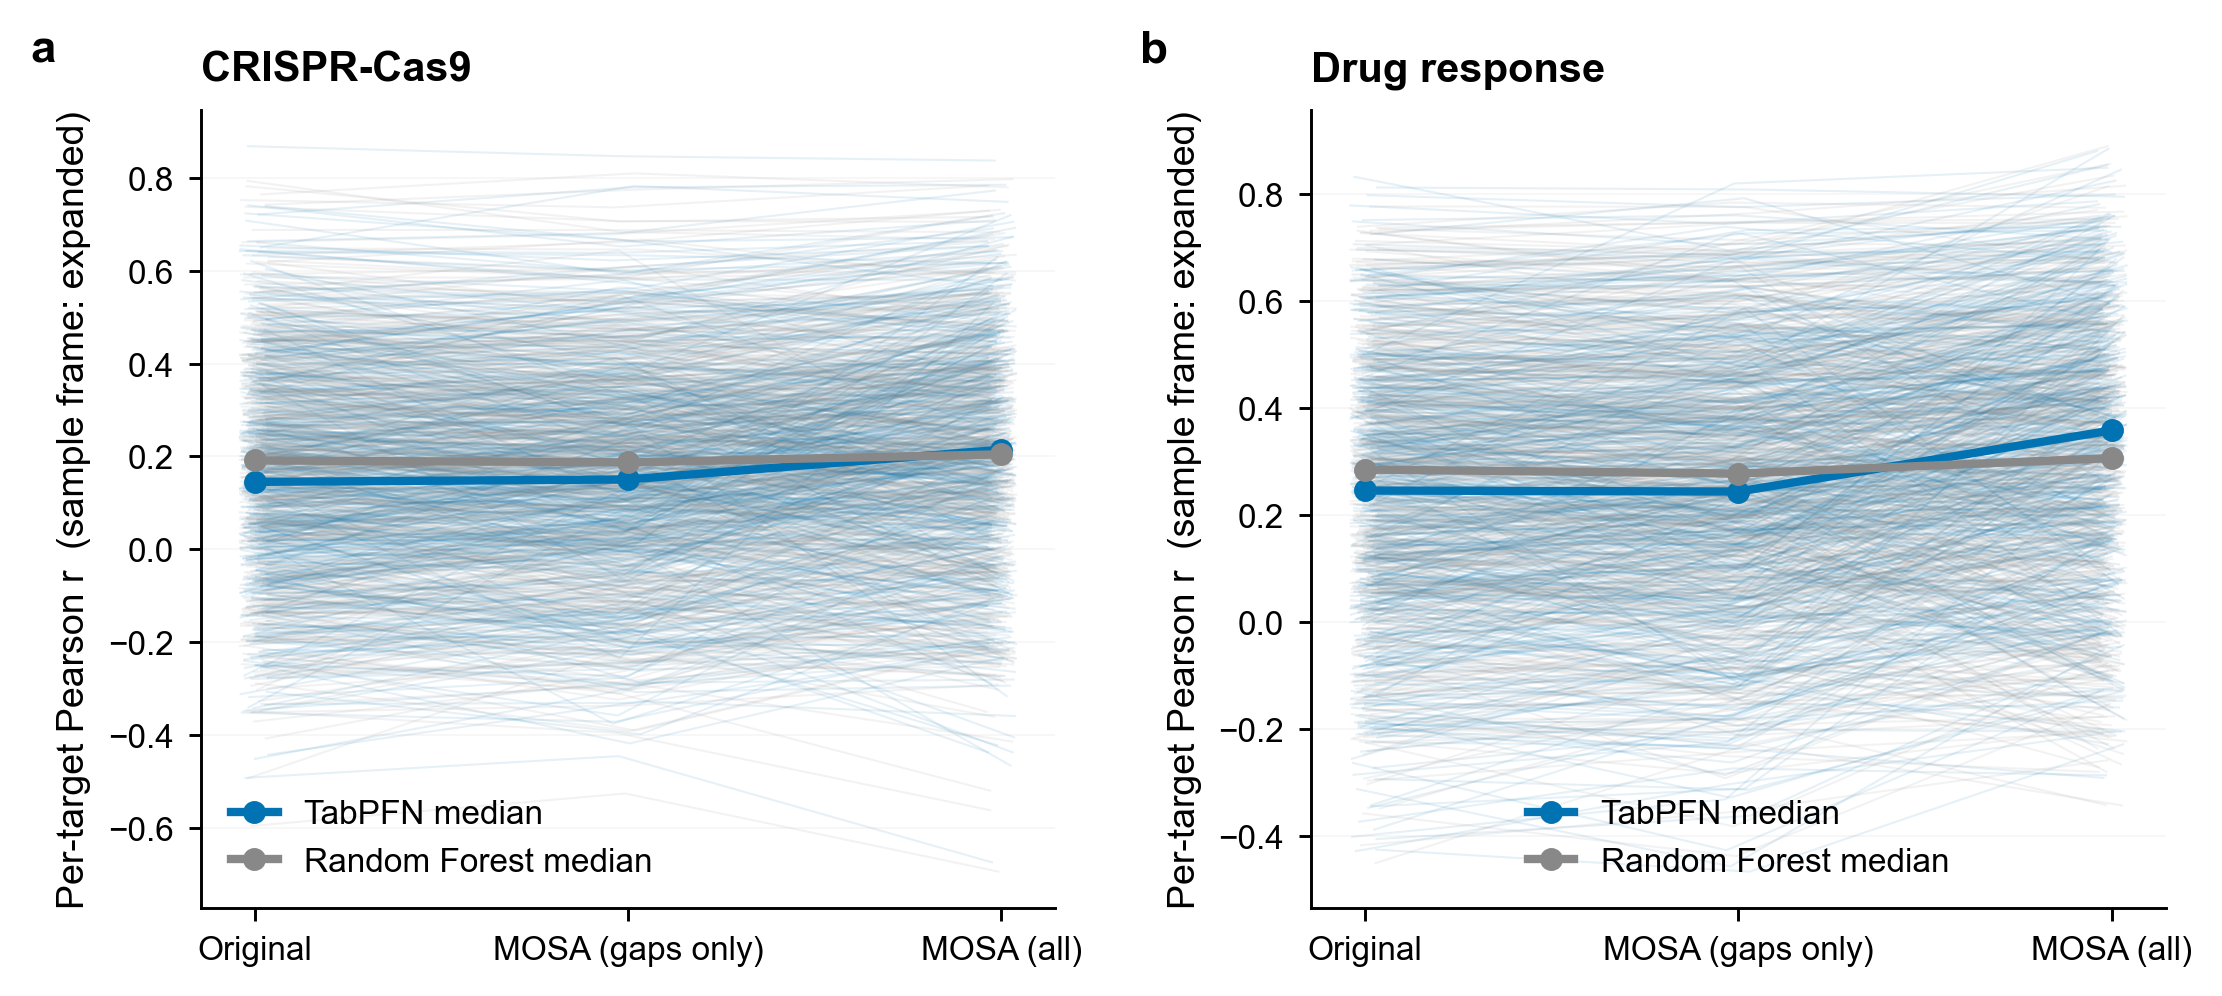

reports/cba2026_claude_union_omicsclin/prediction_analysis/20260511_174623/figP8_strategy_per_target.pdf


In [5]:
p8 = pred.figP8_strategy_per_target(decomposed)
display(Image(filename=str(p8.with_suffix(".png"))))
print(p8.relative_to(pred.ROOT))

## Slide-friendly singles for these four composites

Includes one single-panel scatter per selected deep-dive target (Fig P6 column) so each can stand alone on its own slide.

In [6]:
singles = [
    pred.single_figP5_top_winners_crispr(decomposed),
    pred.single_figP5_top_winners_drug(decomposed),
]
singles.extend(pred.render_singles_figP6_per_target(decomposed, selected))
singles.extend([
    pred.single_figP7d_lever_summary(decomposed),
    pred.single_figP8_strategy_crispr(decomposed),
    pred.single_figP8_strategy_drug(decomposed),
])
for p in singles:
    print(p.relative_to(pred.ROOT))

reports/cba2026_claude_union_omicsclin/prediction_analysis/20260511_174623/singles/single_figP5_top_winners_crispr.pdf
reports/cba2026_claude_union_omicsclin/prediction_analysis/20260511_174623/singles/single_figP5_top_winners_drug.pdf
reports/cba2026_claude_union_omicsclin/prediction_analysis/20260511_174623/singles/single_figP6_deepdive_crisprcas9_MDM2.pdf
reports/cba2026_claude_union_omicsclin/prediction_analysis/20260511_174623/singles/single_figP6_deepdive_crisprcas9_MDM4.pdf
reports/cba2026_claude_union_omicsclin/prediction_analysis/20260511_174623/singles/single_figP6_deepdive_crisprcas9_THOC2.pdf
reports/cba2026_claude_union_omicsclin/prediction_analysis/20260511_174623/singles/single_figP6_deepdive_drugresponse_KN_93.pdf
reports/cba2026_claude_union_omicsclin/prediction_analysis/20260511_174623/singles/single_figP6_deepdive_drugresponse_Rosiglitazone_Maleate.pdf
reports/cba2026_claude_union_omicsclin/prediction_analysis/20260511_174623/singles/single_figP6_deepdive_drugrespons

## Tables — top gainers / losers and selected-target residuals

In [7]:
table_paths = pred.write_prediction_tables(
    summary_long, per_target_long, decomposed, selected_targets=selected,
)
import pandas as pd
gain = pd.read_csv(table_paths["prediction_top_gainers"])
gain[
    ["target_family", "target_name", "direction",
     "r_rf_orig", "r_tabpfn_mosa_all", "delta_headline"]
].round(3).head(20)

,target_family,target_name,direction,r_rf_orig,r_tabpfn_mosa_all,delta_headline
0,crisprcas9,THOC2,top_gain,-0.120,0.500,0.620
1,crisprcas9,BARD1,top_gain,-0.138,0.466,0.604
2,crisprcas9,RBM39,top_gain,-0.104,0.491,0.595
3,crisprcas9,SMARCC1,top_gain,0.155,0.724,0.568
4,crisprcas9,POLR3A,top_gain,-0.287,0.268,0.556
5,crisprcas9,TAF1B,top_gain,0.082,0.629,0.547
6,crisprcas9,HIST1H3C,top_gain,-0.166,0.355,0.522
7,crisprcas9,HAUS2,top_gain,-0.283,0.226,0.510
8,crisprcas9,VPS25,top_gain,0.032,0.538,0.506
9,crisprcas9,HMGCS1,top_gain,-0.168,0.327,0.494


In [8]:
residuals = pd.read_csv(table_paths["prediction_selected_target_residuals"])
residuals.groupby(["target_family", "target_name"]).apply(
    lambda d: pd.Series({
        "n": len(d),
        "r_tabpfn": d[["y_true", "y_pred_tabpfn"]].dropna().corr().iloc[0, 1],
        "r_rf":     d[["y_true", "y_pred_rf"]].dropna().corr().iloc[0, 1],
    })
).round(3)

n  r_tabpfn   r_rf
target_family target_name                                 
crisprcas9    MDM2                   24.0     0.837  0.792
              MDM4                   24.0     0.652  0.461
              THOC2                  24.0     0.500 -0.120
drugresponse  Daunorubicin_HCl       24.0     0.333 -0.271
              KN_93                  24.0     0.618 -0.062
              Rosiglitazone_Maleate  24.0     0.563 -0.075